In [1]:
import os
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scvi
import seaborn as sns
from scvi.external import MRVI

scvi.settings.seed = 0  # optional: ensures reproducibility
print("Last run with scvi-tools version:", scvi.__version__)
save_dir = tempfile.TemporaryDirectory()

/Users/noahbenjamin/Documents/School Work/Research/mrvi-reproducibility/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Seed set to 0


Last run with scvi-tools version: 1.4.0.post1


In [6]:
adata_path = os.path.join(save_dir.name, "haniffa_tutorial_subset.h5ad")

adata = sc.read(adata_path, backup_url="https://figshare.com/ndownloader/files/46017615")
sc.pp.highly_variable_genes(
    adata, n_top_genes=10000, inplace=True, subset=True, flavor="seurat_v3"
)
adata

100%|██████████| 294M/294M [00:30<00:00, 9.98MB/s] 


AnnData object with n_obs × n_vars = 30000 × 10000
    obs: 'sample_id', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'full_clustering', 'initial_clustering', 'Resample', 'Collection_Day', 'Sex', 'Age_interval', 'Swab_result', 'Status', 'Smoker', 'Status_on_day_collection', 'Status_on_day_collection_summary', 'Days_from_onset', 'Site', 'time_after_LPS', 'Worst_Clinical_Status', 'Outcome', 'patient_id', 'age_int'
    var: 'feature_types', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg'

In [8]:
sample_key = "patient_id"  # target covariate
# batch_key="Site"  # nuisance variable identifier
MRVI.setup_anndata(adata, sample_key=sample_key, backend="torch")

model = MRVI(adata, backend="torch")
model.train(max_epochs=4)

/var/folders/hb/lykdnvf57rdd76_sp93dtjm80000gn/T/ipykernel_58483/227017117.py:3: UserWarning: MRVI model is being setup with PyTorch backend
  MRVI.setup_anndata(adata, sample_key=sample_key, backend="torch")
/Users/noahbenjamin/Documents/School Work/Research/mrvi-reproducibility/.venv/lib/python3.13/site-packages/scvi/train/_trainrunner.py:84: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/Users/noahbenjamin/Documents/School Work/Research/mrvi-reproducibility/.venv/lib/python3.13/site-packages/lightning/pytorch/trainer/setup.py:166: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/Users/noahbenjamin/Documents/School Wor

Epoch 4/4: 100%|██████████| 4/4 [00:28<00:00,  7.09s/it, v_num=1, train_loss=1.42e+3]

`Trainer.fit` stopped: `max_epochs=4` reached.


Epoch 4/4: 100%|██████████| 4/4 [00:28<00:00,  7.15s/it, v_num=1, train_loss=1.42e+3]


In [10]:
u = model.get_latent_representation()
adata.obsm["u"] = u
sc.pp.neighbors(adata, use_rep="u")
sc.tl.umap(adata, min_dist=0.3)

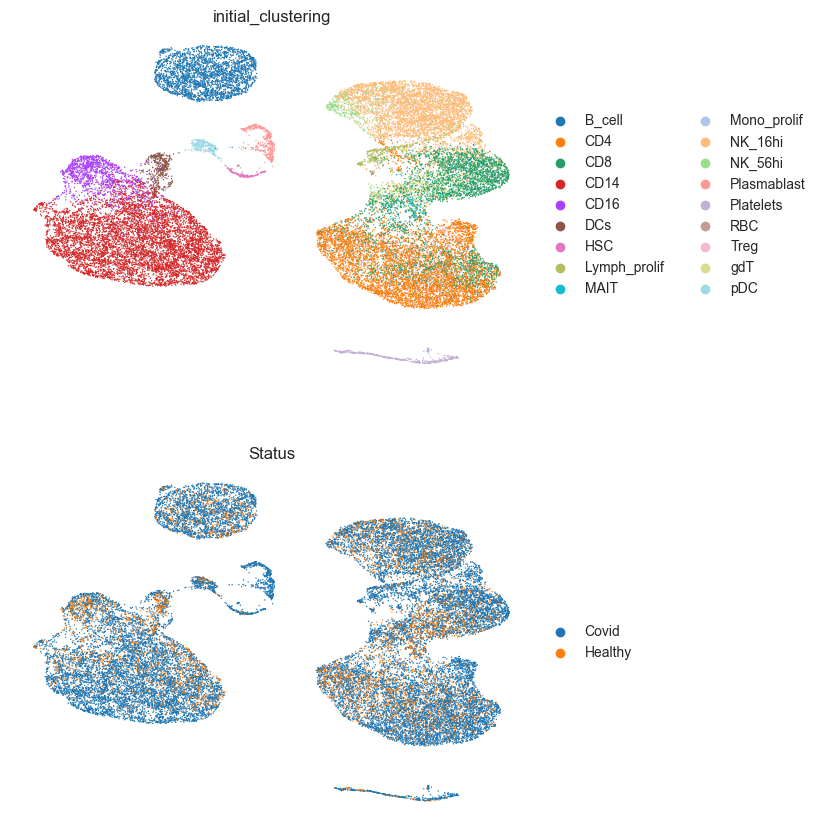

In [11]:
sc.pl.umap(
    adata,
    color=["initial_clustering", "Status"],
    frameon=False,
    ncols=1,
)